# Tutorial to least squares and recursive least squares applied to geolocation simulation

In [ ]:
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedHTMLCommon {
    max-width: 60vw;
    line-height: 1.5;
}
</style>
"""))

## Linearization of equations for geolocation

In this project, the problem for seizure localization will be defined as an angle of arrival problem.  
  
To locate a seizure (emitter) at a position $\vec{t} = [t_x,\ t_y,\ t_z]^T$ from electrodes (sensors) at $\vec{r}_i = [r_x,\ r_y,\ r_z]^T$, triangulation by law of sines 
can be used to geolocate a seizure from estimated bearing angles from multiple electrodes. 
However, as it stands, these measurements are noisy. In this case, an estimator must be used to geolocate the seizure. 
  
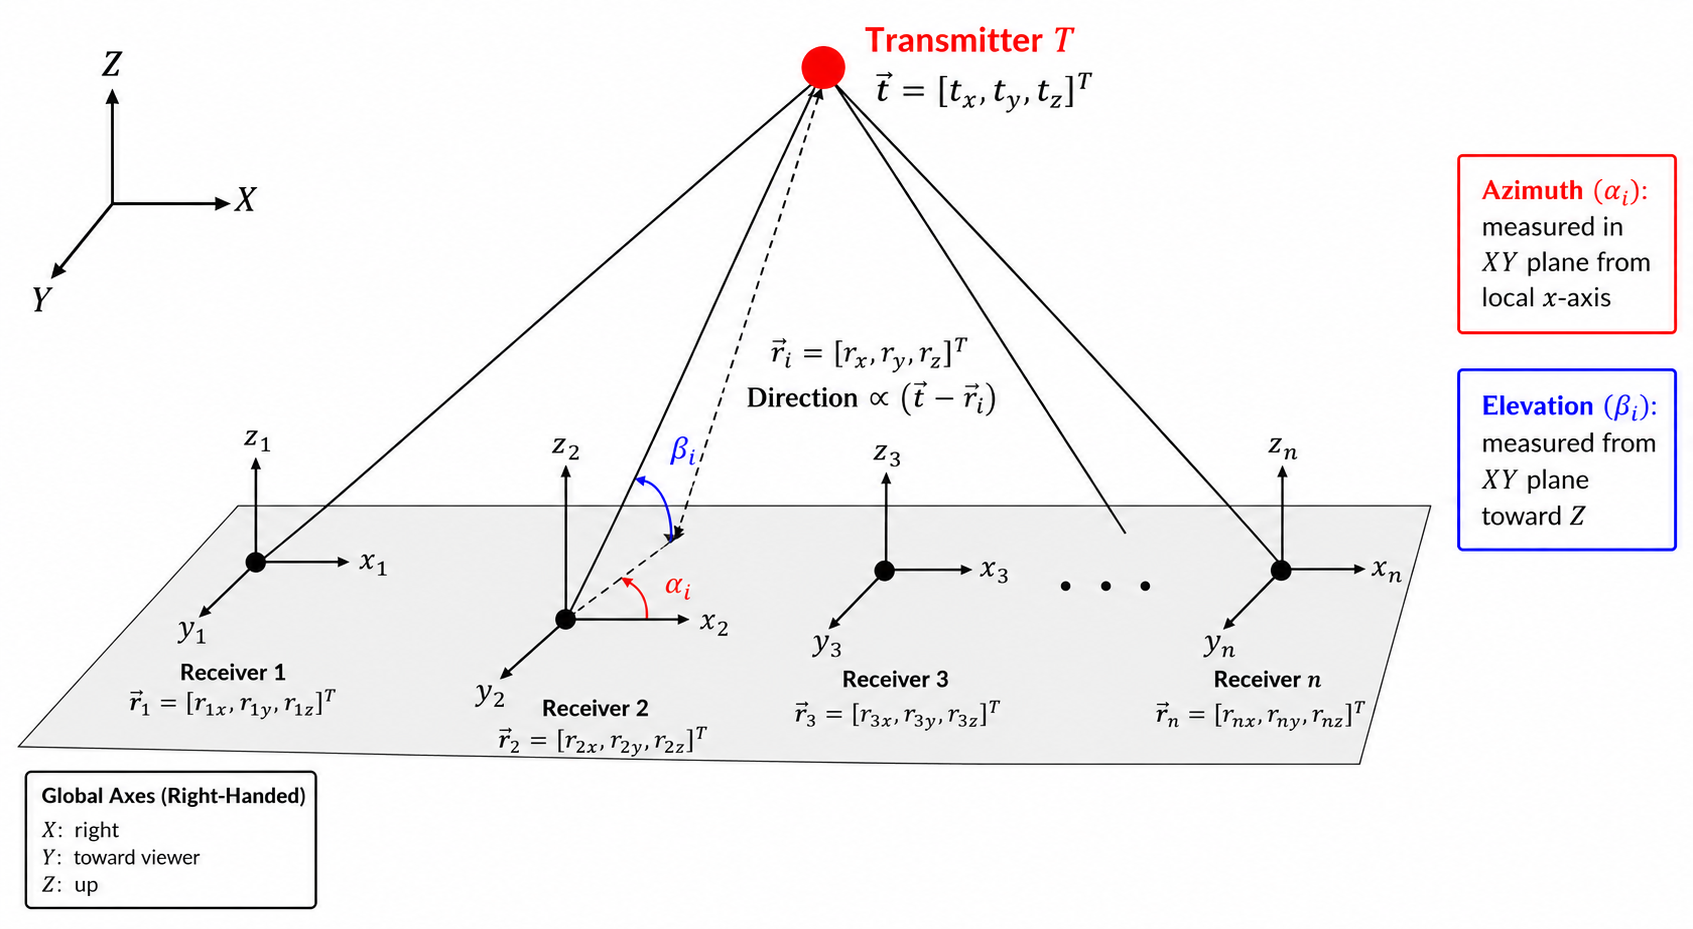
Let $\alpha_{ri}$ denote the “azimuth”, or the bearing angle measured at the ith receiver relative to a baseline in an XY plane coordinate system and  $\beta_{ri}$ denote the “elevation”, or the bearing angle measured at ith receiver relative to a baseline in an Z vs (XY) plane coordinate system, and $n_{\alpha i}$ and $n_{\beta i}$ are their respective error distributions [1]. 

$$\alpha_{ri} = \operatorname{atan}\left(\frac{t_y - r_{yi}}{t_x - r_{xi}}\right) + n_{\alpha i},\qquad-\frac{\pi}{2} \leq \alpha_{ri} \leq \frac{\pi}{2}$$


$$\beta_{ri} =\operatorname{atan}\left(\frac{t_z - r_{zi}}{\sqrt{(t_x - r_{xi})^2 + (t_y - r_{yi})^2}}\right)+ n_{\beta i},\qquad-\frac{\pi}{2}\leq\beta_{ri}\leq\frac{\pi}{2}$$

Combining each of these angle measurements from different sensors result in the above nonlinear system of equations. 
To avoid resolving nonlinear equations, classically, this problem can be solved by Torrieri’s approach [2] by 
linearizing the above function by expanding it in a Taylor series around a reference point. 
However, the solution for the above requires knowledge of the distance from the each of the sensors from the transmitter. 
A non-iterative solution for AoA without knowledge of distance can be approached as follows, 
by applying following auxiliary angle geometric relationships defined in [1], yielding to a system of equations expressed in matrix form: 


$$\mathbf{A}X=\mathbf{B}$$  
  
Where: 
$$X = \vec{t}$$  
$$
\mathbf{A} =
\begin{bmatrix}
\sin(\alpha_1) & -\cos(\alpha_1) & 0 \\
\cos(\alpha_1)\sin(\beta_1) & \sin(\alpha_1)\sin(\beta_1) & -\cos(\beta_1) \\
\sin(\alpha_2) & -\cos(\alpha_2) & 0 \\
\vdots & \vdots & \vdots \\
\sin(\alpha_n) & -\cos(\alpha_n) & 0 \\
\cos(\alpha_n)\sin(\beta_n) & \sin(\alpha_n)\sin(\beta_n) & -\cos(\beta_n)
\end{bmatrix}
$$
  
  
$$
\mathbf{B} =
\begin{bmatrix}
r_{x1}\sin(\alpha_1) - r_{y1}\cos(\alpha_1) \\
r_{x1}\cos(\alpha_1)\sin(\beta_1)
+ r_{y1}\sin(\alpha_1)\sin(\beta_1)
- r_{z1}\cos(\beta_1) \\
r_{x2}\sin(\alpha_2) - r_{y2}\cos(\alpha_2) \\
\vdots \\
r_{xn}\sin(\alpha_n) - r_{yn}\cos(\alpha_n) \\
r_{xn}\cos(\alpha_n)\sin(\beta_n)
+ r_{yn}\sin(\alpha_n)\sin(\beta_n)
- r_{zn}\cos(\beta_n)
\end{bmatrix}
$$
  
And  
$$
\mathbf{A}_k \in \mathbb{R}^{2n \times 3},
\quad
\mathbf{X} \in \mathbb{R}^{3 \times 1},
\quad
\mathbf{B}_k \in \mathbb{R}^{2n \times 1}
$$
  
i = 1,2, ... nth receiver. 

#### Python imports
Prior to beginning this jupyter-notebook tutorial, we can include some python imports.  
Below we also initialize some parameters based on the LS applications for geolocation mentioned above 

In [ ]:
import os
import numpy as np
import geolocation.estimator as estimator
from geolocation.estimator import EstimatorAoA
import geolocation.sensor as sensor
import geolocation.controller as controller

from geolocation.analysis import * 
from geolocation.noise import GaussianNoise

## INITIALIZE ENVIRONMENT 
## INITIALIZE SENSOR AND EMITTER OBJECTS
mu, sig = 0, 17.2
myNoise = GaussianNoise(mu=mu, sigma=sig)

# Set sensors, on top of brain locations. 
a = [1,0,0.8]
b = [-1,0,0.8]
c = [0,1,0.5]
d = [0,-1, 0.5]

# Set z, the seizure inside temporal lobe bounds: 
# bounds = [[-0.6, 0.6],[-0.25, 0.5],[-0.4, 0.1]]
z = [0.2,-0.1,-0.2]

aS = sensor.Sensor("a",a[0],a[1],a[2])
bS = sensor.Sensor("b",b[0],b[1],b[2])
cS = sensor.Sensor("c",c[0],c[1],c[2])
dS = sensor.Sensor("d",d[0],d[1],d[2])

mySeizure = sensor.Sensor("Seizure",z[0],z[1],z[2])
sensor_list = [aS,bS,cS,dS]
num_sens = 4
sensor_list = sensor_list[:num_sens]

for sen in sensor_list:
    sen.set_noise(myNoise)

##  Small introduction to Least Squares

### Least Squares background and formulation 

<font color ='red'> TODO </font>
$$
\hat{\mathbf{X}}
=
\underset{\mathbf{X} \in \mathbb{R}^{3 \times 1}}{\operatorname{arg\,min}}
\;
\left\|
\mathbf{A}\mathbf{X}
-
\mathbf{B}
\right\|_2^2
$$
  
Resulting in the Moore-Penrose pseudo-inverse. 

### Least Squares for geolocation

Given the problem to solve is of form: 

$$\mathbf{A}X=\mathbf{B}$$  
  
We can apply the LS solution with the following below: 
$$\mathbf{X}_{LS} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{B}$$  

In the codebase, the A and B matrices are already defined and LS estimation can be applied with the below code. 
Also note that this formulation is per estimate. For a geolocation problem, as continued angle estimates are detected. 
This estimator only applies an estimate based on the jth sample without knowledge of past samples.

In [ ]:
class LeastSQ(EstimatorAoA):
    def __init__(self, name='leastSQ_default'):
        super().__init__(name)

    def estimate(self, emitter):
        # pos_est , _ , _ , _ = np.linalg.lstsq(self.A_mat, self.b_vec)
        pos_est = np.linalg.inv(self.A_mat.T @ self.A_mat) @ self.A_mat.T @ self.b_vec
        self.estimate_ans = pos_est
        self.estimate_error(emitter)

## Batch Least Squares

Why can't we use all the prior angle information?  
Yes we can! 
The idea for Batched least squares is to collect all the samples and provide an estimate for the whole system.  
This comes with assumptions that the seizure is not moving and that noise distributions stay the same. 

Suppose we collect K samples over time. Each sample results in a series of linear equations:  
  
$$\mathbf{A}_{k}X=\mathbf{B}_{k}$$  
  
For k = 1, 2 ... K samples
We assume noise changes per snapshot and the position of our seizure is not moving. 
Our goal would be then to solve this optimization problem: 

$$
\hat{\mathbf{X}}
=
\underset{\mathbf{X} \in \mathbb{R}^{3 \times 1}}{\operatorname{arg\,min}}
\;
\sum_{k=1}^{K}
\left\|
\mathbf{A}_k \mathbf{X}
-
\mathbf{B}_k
\right\|_2^2
$$

### Batch Least Squares Linear Algebra

For the L2 Squared norm, note the identity:  
  
$$
\sum_{k=1}^{K}
\left\|
\mathbf{A}_k \mathbf{X}
-
\mathbf{B}_k
\right\|_2^2
=
\left\|
\mathbf{A}_{\text{stack}} \mathbf{X}
-
\mathbf{B}_{\text{stack}}
\right\|_2^2
$$  
Where:  

$$
\mathbf{A}_{\text{stack}} \mathbf{X}
-
\mathbf{B}_{\text{stack}}
=
\underbrace{
\begin{bmatrix}
\mathbf{A}_1 \\
\mathbf{A}_2 \\
\vdots \\
\mathbf{A}_K
\end{bmatrix}
}_{\mathbf{A}_{\text{stack}} \in \mathbb{R}^{(2nK) \times 3}}
\mathbf{X}
-
\underbrace{
\begin{bmatrix}
\mathbf{B}_1 \\
\mathbf{B}_2 \\
\vdots \\
\mathbf{B}_K
\end{bmatrix}
}_{\mathbf{B}_{\text{stack}} \in \mathbb{R}^{(2nK) \times 1}}
$$  

Which then results in a similar LS formulation of:  
$$
\hat{\mathbf{X}} =
\left(
\mathbf{A}_{\text{stack}}^T
\mathbf{A}_{\text{stack}}
\right)^{-1}
\mathbf{A}_{\text{stack}}^T
\mathbf{B}_{\text{stack}}
$$

$$
\hat{\mathbf{X}} =
\left(
\sum_{k=1}^{K}
\mathbf{A}_k^T \mathbf{A}_k
\right)^{-1}
\left(
\sum_{k=1}^{K}
\mathbf{A}_k^T \mathbf{B}_k
\right)
$$

$$
\sum_{k=1}^{K}
\mathbf{A}_k^T \mathbf{A}_k
\;\in\;
\mathbb{R}^{3 \times 3}
$$

$$
\sum_{k=1}^{K}
\mathbf{A}_k^T \mathbf{B}_k
\;\in\;
\mathbb{R}^{3 \times 1}
$$

### Batch Least Squares for geolocation  

Below is a function that applies batch least squares as samples are received forwards in time.
The function collects previous applied A and B matrices, appends them to stacked matrices, and computes pseudo-inverse.  
A key concern for this application has is its increasing memory and computation costs because the A and B matrices grow with incoming samples.   
If desired, the function can be maniputated to only keep a certain number of samples by throwing away the oldest past examples and update the stacked matrices with new ones. 


In [ ]:
def rolling_append(original: np.ndarray, new_data: np.ndarray) -> np.ndarray:
    '''
    Append new_data to the end of original while removing
    the same number of entries from the front.

    Works for arrays of any dimensionality along axis 0.
    '''

    original = np.asarray(original)
    new_data = np.asarray(new_data)

    n_remove = new_data.shape[0]

    if n_remove > original.shape[0]:
        raise ValueError("new_data cannot be larger than original along axis 0")

    return np.concatenate((original[n_remove:], new_data), axis=0)

class BatchedLeastSQ(EstimatorAoA):
    def __init__(self, batch=0, name='BatchedleastSQ_default'):
        super().__init__(name)
        self.A_mat_st = np.empty((0, 3))
        self.b_vec_st = np.empty((0, 1))
        self.batch_count = batch
        self.sample_count = 0

    def estimate(self, emitter):
        ## Count, if beyond the count, apply rolling append. Otherwise, just stack 
        if self.batch_count > self.sample_count or self.batch_count < 1:
            self.A_mat_st = np.concatenate((self.A_mat_st, self.A_mat), axis=0)
            self.b_vec_st = np.concatenate((self.b_vec_st, self.b_vec), axis=0)
            self.sample_count += 1
        else: 
            self.A_mat_st = rolling_append(self.A_mat_st, self.A_mat)
            self.b_vec_st = rolling_append(self.b_vec_st, self.b_vec)
        
        ## Estimate 
        # pos_est , _ , _ , _ = np.linalg.lstsq(self.A_mat, self.b_vec)
        pos_est = np.linalg.inv(self.A_mat_st.T @ self.A_mat_st) @ self.A_mat_st.T @ self.b_vec_st
        self.estimate_ans = pos_est
        self.estimate_error(emitter)
        


## Recursive Least Squares

Due to having to increase memory and computation costs for batched LS, can we derive an estimator without throwing away the oldest past examples?
Perhaps a current estimator can be derived from a previuos estimator. This "recursive" estimator would also have the added benefit of
enabling us to make estimations online - or to be able to make inferences as data is streamed. 

<font color ='red'> TODO </font>

### Recursive Least Squares Math

From the batch LS: 

$$
\hat{\mathbf{X}} =
\left(
\sum_{k=1}^{K}
\mathbf{A}_k^T \mathbf{A}_k
\right)^{-1}
\left(
\sum_{k=1}^{K}
\mathbf{A}_k^T \mathbf{B}_k
\right)
$$  

Redefine variables as: 

$$
\mathbf{X}_{K}
=
\mathbf{S}_{K}^{-1}
\mathbf{q}_{K}
=
\mathbf{P}_{K}
\mathbf{q}_{K}
$$

When a new sample arrives, by definition of a summation above we can update the next S and q: 

$$
\mathbf{S}_{K+1}
=
\mathbf{S}_{K}
+
\mathbf{A}_{K+1}^T
\mathbf{A}_{K+1}
$$

$$
\mathbf{q}_{K+1}
=
\mathbf{q}_K
+
\mathbf{A}_{K+1}^T
\mathbf{B}_{K+1}
$$

The mathmatically thorough version of the least square equation applies the Sherman–Morrison–Woodbury identity, but for our case, we can simply invert $\mathbf{S}_{K+1}$ to get $\mathbf{P}_{K+1}$ 

$$
\mathbf{P}_{K+1}
=
(\mathbf{S}_{K}
+
\mathbf{A}_{K+1}^T
\mathbf{A}_{K+1})^{-1}
$$

### Updating the estimate

We define the update of the estimate as follows: 
$$
\mathbf{X}_{K+1}
=
\mathbf{P}_{K+1}
\mathbf{q}_{K+1}
$$

From above, we have defined all the parts to perform this update being: $\mathbf{P}_{K+1}$ and $\mathbf{q}_{K+1}$  



$$
\mathbf{X}_{K+1}
=
\mathbf{P}_{K+1}
\mathbf{q}_{K+1}
$$

$$
\mathbf{X}_{K+1}
=
\mathbf{P}_{K+1}
\left(
\mathbf{S}_K \mathbf{X}_K
+
\mathbf{H}_{K+1}^T
\mathbf{Z}_{K+1}
\right)
$$

$$
\mathbf{S}_K
=
\mathbf{S}_{K+1}
-
\mathbf{H}_{K+1}^T
\mathbf{H}_{K+1}
$$

$$
\mathbf{X}_{K+1}
=
\mathbf{P}_{K+1}
\left(
(\mathbf{S}_{K+1}
-
\mathbf{H}_{K+1}^T
\mathbf{H}_{K+1})
\mathbf{X}_K
+
\mathbf{H}_{K+1}^T
\mathbf{Z}_{K+1}
\right)
$$

$$
\mathbf{X}_{K+1}
=
\mathbf{P}_{K+1}
\mathbf{S}_{K+1}
\mathbf{X}_K
-
\mathbf{P}_{K+1}
\mathbf{H}_{K+1}^T
\mathbf{H}_{K+1}
\mathbf{X}_K
+
\mathbf{P}_{K+1}
\mathbf{H}_{K+1}^T
\mathbf{Z}_{K+1}
$$

$$
\mathbf{X}_{K+1}
=
\mathbf{X}_K
-
\mathbf{P}_{K+1}
\mathbf{H}_{K+1}^T
\mathbf{H}_{K+1}
\mathbf{X}_K
+
\mathbf{P}_{K+1}
\mathbf{H}_{K+1}^T
\mathbf{Z}_{K+1}
$$

$$
\mathbf{X}_{K+1}
=
\mathbf{X}_K
+
\mathbf{P}_{K+1}
\mathbf{H}_{K+1}^T
\left(
\mathbf{Z}_{K+1}
-
\mathbf{H}_{K+1}
\mathbf{X}_K
\right)
$$

$$
\mathbf{K}_{K+1}
=
\mathbf{P}_{K+1}
\mathbf{H}_{K+1}^T
$$

$$
\mathbf{X}_{K+1}
=
\mathbf{X}_K
+
\mathbf{K}_{K+1}
\left(
\mathbf{Z}_{K+1}
-
\mathbf{H}_{K+1}
\mathbf{X}_K
\right)
$$

To conclude, RLS is one of many recursive methods for solving the least squares. It also provides a foundation to the kalman filter, which can be used instead if the target is moving. 

In [ ]:
class RecursiveLeastSQ(EstimatorAoA):
    def __init__(self, lambda_, P0=1e-3, name='recursiveLeastSQ_default'):
        Q = ((1 - lambda_) / lambda_) * P0 * np.eye(3)
        R = 1.0
        super().__init__(Q=Q,R=R,P0=1e3,name=name)

    def generate_est_matrices(self, slist):
        super().generate_est_matrices(slist)
        self.R = self.R*np.eye(self.A_mat.shape[0])

    def estimate(self, emitter):
        # Prediction
        pass



#### Initialize your Estimator Here: 

In [ ]:
## INITIALIZE ESTIMATOR HERE
myEstimator = estimator.RecursiveLeastSQ(1)
#myEstimator = BatchedLeastSQ()
#myEstimator = LeastSQ()

#### Run a Geolocation simulation here: 

In [ ]:
## INITIALIZE CONTROLLER 
rng = np.random.default_rng(10)
mc_count = 1000
## TODO, Controller should take in environment, and run environment setup here, rather than manually 
#        affecting the sensor relocation earlier in this main script 
myController = controller.Controller(mySeizure, 
                                    sensor_list, 
                                    myEstimator,
                                    mc_count = mc_count, rng=rng)
myController.run_simulation()

In [ ]:
# TODO: consider removing this from controller and have it all from the estimator object instead. 
# Controller only runs the simulation, not keeps values from it. 
all_pos_est = myController.all_pos_est
all_pos_err = myController.all_pos_err


# plotVer_2D(mySeizure,sensor_list,estimates=all_pos_est)
plot_err(mc_count, est=all_pos_est, err=all_pos_err, scale=9)

# KF Specific
#kf_params = myRLS.get_KF_update_metrics()
#p_hist = kf_params["P_hist"]

#plot_track_cov(mySeizure, p_hist=p_hist)


## References

[1] C. Wang, W. Fu, T. Zhang, M. Zeng, and H. Cheng, “An AOA Optimal Positioning Method Incorporating Station Error and Sensor Deployment,” Aerospace, vol. 9, no. 12, pp. 766–766, Nov. 2022, doi: https://doi.org/10.3390/aerospace9120766  
[22] D. Torrieri, “Statistical Theory of Passive Location Systems,” IEEE Trans. Aerosp. Electron. Syst., vol. AES-20, no. 2, pp. 183–198, Mar. 1984, doi: 10.1109/TAES.1984.310439. [24] https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=1045433
